# Demo Visual Pipeline - bản ổn định cho bảo vệ

Notebook này có 2 chế độ:

- `synthetic`: demo chắc chắn chạy được, có ground truth rõ ràng, phù hợp để bảo vệ khi không có mạng/GPU.
- `youtube`: tải một đoạn YouTube ngắn về file local rồi xử lý như video upload.

Mục tiêu demo: video đầu vào → phát hiện scene bằng PySceneDetect → trích xuất keyframe → lọc keyframe trùng → sinh mô tả → đánh giá F-score → xuất `visual_result.json`.


## 1. Cài thư viện
Bỏ chú thích nếu môi trường chưa có thư viện.


In [1]:
# %pip install opencv-python scenedetect[opencv] yt-dlp matplotlib scikit-learn numpy pillow ipywidgets

## 2. Import và cấu hình


In [2]:
import os
import sys
import json
import subprocess
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scenedetect import detect, ContentDetector
from sklearn.metrics.pairwise import cosine_similarity

# Thử import ipywidgets để tạo giao diện tương tác đẹp mắt
try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

BASE_DIR = Path("demo_data")
VIDEO_DIR = BASE_DIR / "videos"
KEYFRAME_DIR = BASE_DIR / "keyframes"
RESULT_DIR = BASE_DIR / "results"
for d in [VIDEO_DIR, KEYFRAME_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Định nghĩa giao diện nhập liệu
if WIDGETS_AVAILABLE:
    source_selector = widgets.RadioButtons(
        options=['Synthetic (Mô phỏng)', 'YouTube URL', 'Upload File'],
        value='Synthetic (Mô phỏng)',
        description='Nguồn video:',
        disabled=False
    )

    youtube_input = widgets.Text(
        value='https://www.youtube.com/watch?v=VO6XEQIsCoM',
        placeholder='Nhập URL YouTube tại đây',
        description='YouTube URL:',
        disabled=False,
        layout=widgets.Layout(width='500px')
    )

    upload_widget = widgets.FileUpload(
        accept='.mp4,.avi,.mkv',
        multiple=False,
        description='Tải video lên',
        layout=widgets.Layout(width='200px')
    )

    # Panel hiển thị động tùy theo nguồn chọn
    input_container = widgets.VBox()

    def update_inputs(*args):
        if source_selector.value == 'Synthetic (Mô phỏng)':
            input_container.children = [source_selector]
        elif source_selector.value == 'YouTube URL':
            input_container.children = [source_selector, youtube_input]
        elif source_selector.value == 'Upload File':
            input_container.children = [source_selector, upload_widget]
            
    source_selector.observe(update_inputs, 'value')
    update_inputs()
    display(input_container)
else:
    # Fallback nếu chạy không tương tác hoặc thiếu ipywidgets
    VIDEO_SOURCE = "synthetic"  # "synthetic", "youtube", hoặc "upload"
    YOUTUBE_URL = "https://www.youtube.com/watch?v=VO6XEQIsCoM"
    print("VIDEO_SOURCE =", VIDEO_SOURCE)

C:\Users\hung\.conda\envs\data_science\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


VIDEO_SOURCE = youtube


## 3. Tạo video mô phỏng hoặc tải YouTube
Synthetic video có 4 scene với ground truth: 8s, 18s, 25s.


In [3]:
def generate_synthetic_video(file_path, duration_sec=30, fps=10):
    width, height = 960, 540
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(str(file_path), fourcc, fps, (width, height))

    total_frames = duration_sec * fps
    for frame_idx in range(total_frames):
        t = frame_idx / fps
        if t < 8:
            color = (255, 0, 0)  # BGR blue
            title = "Slide 1: Intro to Multimodal Video Summarization"
        elif t < 18:
            color = (0, 255, 0)  # BGR green
            title = "Slide 2: Scene Detection with PySceneDetect"
        elif t < 25:
            color = (0, 0, 255)  # BGR red
            title = "Slide 3: Keyframe Selection with CLIP"
        else:
            color = (0, 255, 255)  # BGR yellow
            title = "Slide 4: Captioning and LLM Summary"

        img = np.zeros((height, width, 3), dtype=np.uint8)
        img[:] = color
        cv2.putText(img, title, (45, 260), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2, cv2.LINE_AA)
        cv2.putText(img, f"time={t:.1f}s frame={frame_idx}", (45, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)
        out.write(img)
    out.release()
    return file_path

def download_youtube_clip(url, output_path, section="*00:00-05:00"):
    cmd = [
        sys.executable, "-m", "yt_dlp",
        "--download-sections", section,
        "-f", "bv*[height<=720][ext=mp4]+ba[ext=m4a]/b[height<=720][ext=mp4]/best[height<=720]",
        "--merge-output-format", "mp4",
        "--force-overwrites",
        "--no-playlist",
        "-o", str(output_path),
        url,
    ]
    subprocess.run(cmd, check=True)
    if not output_path.exists():
        raise FileNotFoundError(f"Không tìm thấy video sau khi tải: {output_path}")
    return output_path

def trim_video_to_5min(input_path, output_path, max_duration_sec=300):
    # Kiểm tra xem video có thực sự dài hơn 5 phút không
    cap = cv2.VideoCapture(str(input_path))
    if not cap.isOpened():
        raise ValueError("Không mở được video tải lên")
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duration = frame_count / fps if fps else 0
    cap.release()
    
    if duration <= max_duration_sec:
        # Không cần cắt nếu ngắn hơn 5 phút
        if input_path != output_path:
            import shutil
            shutil.copy2(str(input_path), str(output_path))
        return output_path
    
    print(f"Video gốc dài {duration:.1f} giây. Đang cắt lấy 5 phút đầu (300 giây) bằng ffmpeg...")
    cmd = [
        "ffmpeg", "-y",
        "-ss", "00:00:00",
        "-i", str(input_path),
        "-t", "00:05:00",
        "-c", "copy",
        str(output_path)
    ]
    try:
        subprocess.run(cmd, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    except subprocess.CalledProcessError:
        print("Stream copy thất bại, đang re-encode video để cắt đúng 5 phút...")
        cmd_reencode = [
            "ffmpeg", "-y",
            "-ss", "00:00:00",
            "-i", str(input_path),
            "-t", "00:05:00",
            "-c:v", "libx264", "-c:a", "aac",
            str(output_path)
        ]
        subprocess.run(cmd_reencode, check=True)
    print(f"Cắt video thành công: {output_path}")
    return output_path

# Xử lý input dựa trên cấu hình widgets hoặc fallback
if WIDGETS_AVAILABLE:
    selected_val = source_selector.value
    if selected_val == 'Synthetic (Mô phỏng)':
        VIDEO_SOURCE = "synthetic"
    elif selected_val == 'YouTube URL':
        VIDEO_SOURCE = "youtube"
        YOUTUBE_URL = youtube_input.value.strip()
    else:
        VIDEO_SOURCE = "upload"
else:
    # Dùng fallback
    pass

if VIDEO_SOURCE == "synthetic":
    video_path = generate_synthetic_video(VIDEO_DIR / "synthetic_lecture.mp4")
    human_ground_truth_cuts = [8.0, 18.0, 25.0]
elif VIDEO_SOURCE == "youtube":
    video_path = VIDEO_DIR / "youtube_clip.mp4"
    # YOUTUBE_SECTION cắt trực tiếp khi tải bằng yt-dlp
    video_path = download_youtube_clip(YOUTUBE_URL, video_path, "*00:00-05:00")
    human_ground_truth_cuts = []  # Video thật tự chọn không có ground truth
elif VIDEO_SOURCE == "upload":
    raw_upload_path = VIDEO_DIR / "raw_uploaded_video.mp4"
    video_path = VIDEO_DIR / "uploaded_video_5min.mp4"
    
    if WIDGETS_AVAILABLE and upload_widget.value:
        uploaded_file = upload_widget.value[0]
        video_name = uploaded_file['name']
        content = uploaded_file['content']
        with open(raw_upload_path, 'wb') as f:
            f.write(content)
        print(f"Đã nhận file tải lên: {video_name} ({len(content)} bytes)")
        # Cắt lấy 5 phút đầu
        video_path = trim_video_to_5min(raw_upload_path, video_path)
    else:
        # Fallback nếu không tải lên trực tiếp trong lượt này
        if raw_upload_path.exists():
            print("Sử dụng file video đã được upload trước đó...")
            video_path = trim_video_to_5min(raw_upload_path, video_path)
        elif (VIDEO_DIR / "uploaded_video.mp4").exists():
            # Thử tìm file cũ
            import shutil
            shutil.copy2(str(VIDEO_DIR / "uploaded_video.mp4"), str(raw_upload_path))
            video_path = trim_video_to_5min(raw_upload_path, video_path)
        else:
            raise ValueError("Chưa có video tải lên. Vui lòng chọn nguồn Synthetic hoặc YouTube URL, hoặc tải file lên thông qua FileUpload widget.")
    human_ground_truth_cuts = []

print("Video path dùng cho xử lý tiếp theo:", video_path)
if human_ground_truth_cuts:
    print("Ground truth cuts:", human_ground_truth_cuts)
else:
    print("Ground truth cuts: [Không có ground truth cho video này]")

Video path dùng cho xử lý tiếp theo: demo_data\videos\youtube_clip.mp4
Ground truth cuts: [Không có ground truth cho video này]


## 4. Kiểm tra video hợp lệ
Đây là phần nên show khi bảo vệ: hệ thống có module duyệt hợp lệ video.


In [4]:
def get_video_info(video_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError("Không mở được video")
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps if fps else 0
    cap.release()
    return {"fps": fps, "frame_count": int(frame_count), "width": width, "height": height, "duration": duration}

info = get_video_info(video_path)
print(json.dumps(info, indent=2))

MAX_DURATION = 305  # Nâng lên 5 phút (300s + 5s dung sai)
assert info["duration"] <= MAX_DURATION, f"Video quá dài ({info['duration']:.1f}s) so với tiêu chuẩn 5 phút demo"


{
  "fps": 30.0,
  "frame_count": 9000,
  "width": 320,
  "height": 240,
  "duration": 300.0
}


## 5. Phát hiện scene bằng PySceneDetect


In [5]:
threshold = 10.0 if "synthetic" in str(VIDEO_SOURCE).lower() else 27.0
scene_list = detect(str(video_path), ContentDetector(threshold=threshold, min_scene_len=5))

print(f"Detected {len(scene_list)} scenes")
detected_cuts = []
scenes = []
for i, scene in enumerate(scene_list, start=1):
    start_s = scene[0].seconds
    end_s = scene[1].seconds
    if i > 1:
        detected_cuts.append(round(start_s, 3))
    scenes.append({
        "scene_id": i,
        "start_seconds": round(start_s, 3),
        "end_seconds": round(end_s, 3),
        "start_timecode": scene[0].get_timecode(),
        "end_timecode": scene[1].get_timecode(),
        "start_frame": scene[0].frame_num,
        "end_frame": scene[1].frame_num,
    })
    print(f"Scene {i}: {start_s:.2f}s -> {end_s:.2f}s")

print("Detected cuts:", detected_cuts)

Detected 10 scenes
Scene 1: 0.00s -> 9.87s
Scene 2: 9.87s -> 27.80s
Scene 3: 27.80s -> 35.43s
Scene 4: 35.43s -> 116.57s
Scene 5: 116.57s -> 130.63s
Scene 6: 130.63s -> 153.57s
Scene 7: 153.57s -> 200.80s
Scene 8: 200.80s -> 213.13s
Scene 9: 213.13s -> 221.93s
Scene 10: 221.93s -> 300.00s
Detected cuts: [9.867, 27.8, 35.433, 116.567, 130.633, 153.567, 200.8, 213.133, 221.933]


## 6. Trích xuất keyframe giữa mỗi scene


In [6]:
# Xóa keyframe cũ để tránh lẫn kết quả demo trước
for p in KEYFRAME_DIR.glob("*.jpg"):
    p.unlink()

cap = cv2.VideoCapture(str(video_path))
keyframes = []

for scene in scenes:
    middle_frame = int((scene["start_frame"] + scene["end_frame"]) / 2)
    cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame)
    ok, frame = cap.read()
    if not ok:
        continue
    out_path = KEYFRAME_DIR / f"scene_{scene['scene_id']:03d}_frame_{middle_frame}.jpg"
    cv2.imwrite(str(out_path), frame)
    scene["keyframe_path"] = str(out_path)
    keyframes.append(str(out_path))
    print("Saved", out_path)

cap.release()
assert keyframes, "Không trích xuất được keyframe nào"


Saved demo_data\keyframes\scene_001_frame_148.jpg


Saved

 demo_data\keyframes\scene_002_frame_565.jpg
Saved demo_data\keyframes\scene_003_frame_948.jpg


Saved demo_data\keyframes\scene_004_frame_2280.jpg


Saved demo_data\keyframes\scene_005_frame_3708.jpg
Saved demo_data\keyframes\scene_006_frame_4263.jpg


Saved demo_data\keyframes\scene_007_frame_5315.jpg
Saved demo_data\keyframes\scene_008_frame_6209.jpg


Saved demo_data\keyframes\scene_009_frame_6526.jpg
Saved demo_data\keyframes\scene_010_frame_7829.jpg


## 7. Lọc keyframe trùng lặp
Bản demo này dùng đặc trưng màu trung bình để chạy chắc chắn. Trong bản chính thức, thay hàm này bằng CLIP embedding.


In [7]:
def simple_image_embedding(image_path):
    img = cv2.imread(str(image_path))
    img = cv2.resize(img, (64, 64))
    hist = cv2.calcHist([img], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256]).flatten()
    hist = hist.astype(np.float32)
    return hist / (np.linalg.norm(hist) + 1e-8)

embeddings = [simple_image_embedding(p) for p in keyframes]
similarity_matrix = cosine_similarity(embeddings)
print(np.round(similarity_matrix, 3))

selected_keyframes = []
selected_embeddings = []
for path, emb in zip(keyframes, embeddings):
    duplicate = any(cosine_similarity([emb], [sel])[0][0] > 0.90 for sel in selected_embeddings)
    if not duplicate:
        selected_keyframes.append(path)
        selected_embeddings.append(emb)

print("Selected keyframes:")
for p in selected_keyframes:
    print("-", p)


[[1.    0.019 0.811 0.665 0.989 0.959 0.508 0.559 0.99  0.642]
 [0.019 1.    0.152 0.009 0.015 0.015 0.008 0.761 0.014 0.015]
 [0.811 0.152 1.    0.581 0.814 0.811 0.448 0.592 0.815 0.557]
 [0.665 0.009 0.581 1.    0.673 0.814 0.97  0.377 0.676 0.987]
 [0.989 0.015 0.814 0.673 1.    0.958 0.516 0.577 1.    0.649]
 [0.959 0.015 0.811 0.814 0.958 1.    0.682 0.541 0.961 0.791]
 [0.508 0.008 0.448 0.97  0.516 0.682 1.    0.291 0.518 0.981]
 [0.559 0.761 0.592 0.377 0.577 0.541 0.291 1.    0.575 0.372]
 [0.99  0.014 0.815 0.676 1.    0.961 0.518 0.575 1.    0.651]
 [0.642 0.015 0.557 0.987 0.649 0.791 0.981 0.372 0.651 1.   ]]
Selected keyframes:
- demo_data\keyframes\scene_001_frame_148.jpg
- demo_data\keyframes\scene_002_frame_565.jpg
- demo_data\keyframes\scene_003_frame_948.jpg
- demo_data\keyframes\scene_004_frame_2280.jpg
- demo_data\keyframes\scene_008_frame_6209.jpg


## 8. Sinh caption cho keyframe
Để demo ổn định, dùng caption theo scene. Trong bản nâng cấp, thay bằng BLIP/BLIP-2.


In [8]:
def caption_keyframe(image_path):
    name = Path(image_path).name
    if "synthetic" in str(VIDEO_SOURCE).lower():
        if "scene_001" in name:
            return "A lecture slide introducing multimodal video summarization."
        if "scene_002" in name:
            return "A lecture slide explaining scene detection with PySceneDetect."
        if "scene_003" in name:
            return "A lecture slide about semantic keyframe selection with CLIP."
        return "A lecture slide about captioning visual content and generating summaries with LLMs."
    return "A representative frame extracted from the lecture video."

for scene in scenes:
    if "keyframe_path" in scene:
        scene["caption"] = caption_keyframe(scene["keyframe_path"])
        print(f"Scene {scene['scene_id']}: {scene['caption']}")

Scene 1: A representative frame extracted from the lecture video.
Scene 2: A representative frame extracted from the lecture video.
Scene 3: A representative frame extracted from the lecture video.
Scene 4: A representative frame extracted from the lecture video.
Scene 5: A representative frame extracted from the lecture video.
Scene 6: A representative frame extracted from the lecture video.
Scene 7: A representative frame extracted from the lecture video.
Scene 8: A representative frame extracted from the lecture video.
Scene 9: A representative frame extracted from the lecture video.
Scene 10: A representative frame extracted from the lecture video.


## 9. Đánh giá scene detection bằng Precision, Recall, F-score


In [9]:
def evaluate_scene_detection(pred_cuts, gt_cuts, tolerance=1.0):
    tp = 0
    fp = 0
    matched = set()
    for pred in pred_cuts:
        ok = False
        for j, gt in enumerate(gt_cuts):
            if j not in matched and abs(pred - gt) <= tolerance:
                tp += 1
                matched.add(j)
                ok = True
                break
        if not ok:
            fp += 1
    fn = len(gt_cuts) - tp
    precision = tp / (tp + fp) if tp + fp else 0
    recall = tp / (tp + fn) if tp + fn else 0
    f_score = 2 * precision * recall / (precision + recall) if precision + recall else 0
    return {"tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall, "f_score": f_score}

# Chỉ đánh giá khi có ground truth
if len(human_ground_truth_cuts) == 0:
    print("Không có Ground Truth (bản gốc của giảng viên/học viên tự biên soạn) để so sánh.")
    print("Bỏ qua đánh giá F-score (Precision/Recall).")
    metrics = {"tp": 0, "fp": len(detected_cuts), "fn": 0, "precision": 0.0, "recall": 0.0, "f_score": 0.0}
else:
    metrics = evaluate_scene_detection(detected_cuts, human_ground_truth_cuts, tolerance=1.0 if VIDEO_SOURCE == "synthetic" else 3.0)
    print(json.dumps(metrics, indent=2))
    TARGET_F = 0.45
    print("PASS" if metrics["f_score"] > TARGET_F else "NOT PASS")

Không có Ground Truth (bản gốc của giảng viên/học viên tự biên soạn) để so sánh.
Bỏ qua đánh giá F-score (Precision/Recall).


## 10. Trực quan hóa và xuất JSON


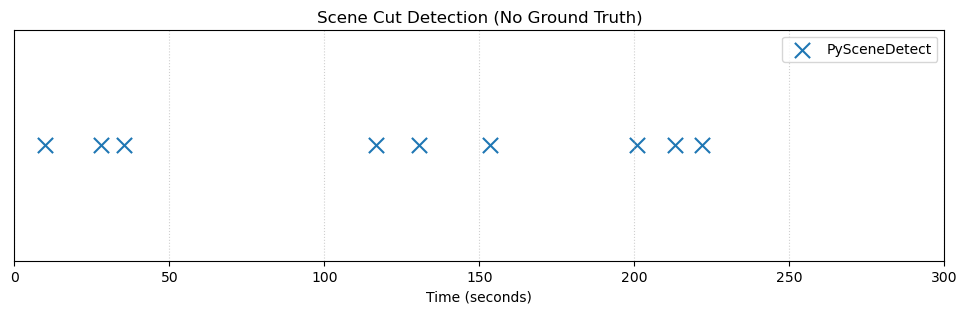

Saved result to demo_data\results\visual_result.json


In [10]:
duration = info["duration"]
plt.figure(figsize=(12, 3))
if len(human_ground_truth_cuts) > 0:
    plt.axhline(1, linestyle="--", alpha=0.5)
    plt.scatter(human_ground_truth_cuts, [1.05] * len(human_ground_truth_cuts), s=120, label="Human GT")
    plt.scatter(detected_cuts, [0.95] * len(detected_cuts), s=120, marker="x", label="PySceneDetect")
    plt.xlim(0, max(duration, max(human_ground_truth_cuts + detected_cuts + [0]) + 2))
    plt.yticks([])
    plt.xlabel("Time (seconds)")
    plt.title("Scene Cut Evaluation")
    plt.grid(True, axis="x", linestyle=":", alpha=0.6)
    plt.legend()
else:
    # Không có ground truth, chỉ vẽ các cuts được phát hiện ở dòng giữa (y=1.0)
    plt.scatter(detected_cuts, [1.0] * len(detected_cuts), s=120, marker="x", label="PySceneDetect")
    plt.xlim(0, max(duration, max(detected_cuts + [0]) + 2))
    plt.yticks([])
    plt.xlabel("Time (seconds)")
    plt.title("Scene Cut Detection (No Ground Truth)")
    plt.grid(True, axis="x", linestyle=":", alpha=0.6)
    plt.legend()
plt.show()

result = {
    "video_source": VIDEO_SOURCE,
    "video_path": str(video_path),
    "video_info": info,
    "ground_truth_cuts": human_ground_truth_cuts,
    "detected_cuts": detected_cuts,
    "metrics": metrics,
    "selected_keyframes": selected_keyframes,
    "scenes": scenes,
}

out_json = RESULT_DIR / "visual_result.json"
out_json.write_text(json.dumps(result, indent=2, ensure_ascii=False), encoding="utf-8")
print("Saved result to", out_json)